# Assignment 1 — Pokemon Type Classification
## Task 2: Convolutional Neural Network (CNN)

**Evaluation metric:** Macro-averaged F1 Score  
**Baseline (MLP):** val macro-F1 = 0.2093  
**Goal:** Improve over the MLP by exploiting spatial structure in images

In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score


In [17]:
BASE_DIR   = os.path.join(os.path.dirname(os.getcwd()), "data") if "notebooks" in os.getcwd() else "data"
TRAIN_DIR  = os.path.join(BASE_DIR, "Train")
TEST_DIR   = os.path.join(BASE_DIR, "Test")
LABELS_CSV = os.path.join(BASE_DIR, "train_labels.csv")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Train dir : {TRAIN_DIR}")
print(f"Labels CSV: {LABELS_CSV}")

Device: cuda
Train dir : c:\MyStuff\FCT\2SEM\AP\Assignment1\DeepLearningFCT\Assignment1\data\Train
Labels CSV: c:\MyStuff\FCT\2SEM\AP\Assignment1\DeepLearningFCT\Assignment1\data\train_labels.csv


## 1. Data Loading & Class Distribution

Total training samples: 3600

Classes (9): ['Bug', 'Fighting', 'Fire', 'Grass', 'Ground', 'Normal', 'Poison', 'Rock', 'Water']

Class distribution:
label
Bug         374
Fighting    291
Fire        381
Grass       299
Ground      244
Normal      606
Poison      467
Rock        264
Water       674

Imbalance ratio: 2.8x


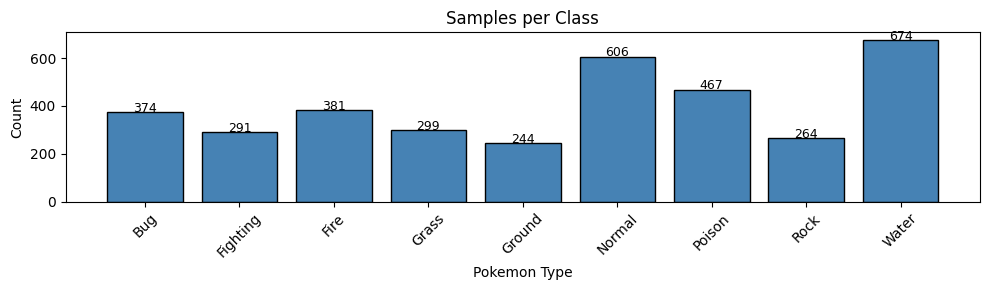

In [18]:
df = pd.read_csv(LABELS_CSV)
print(f"Total training samples: {len(df)}")

class_counts = df['label'].value_counts().sort_index()
print(f"\nClasses ({df['label'].nunique()}): {sorted(df['label'].unique())}")
print(f"\nClass distribution:")
print(class_counts.to_string())
print(f"\nImbalance ratio: {class_counts.max() / class_counts.min():.1f}x")

plt.figure(figsize=(10, 3))
plt.bar(class_counts.index, class_counts.values, color='steelblue', edgecolor='black')
plt.title("Samples per Class")
plt.xlabel("Pokemon Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 2, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 2. Dataset & DataLoader

Key difference from Task 1: images are **not flattened**. The CNN receives tensors of shape `(3, H, W)` and learns spatial features through convolutional filters.

In [19]:
IMG_SIZE   = 128
BATCH_SIZE = 64
VAL_RATIO  = 0.15
N_WORKERS  = 0
LR         = 3e-4
MAX_EPOCHS = 60
PATIENCE   = 10
DROPOUT    = 0.4

RUN_NAME = f"cnn_img{IMG_SIZE}_lr{LR}_bs{BATCH_SIZE}_drop{DROPOUT}"
RUN_DIR  = os.path.join(os.path.dirname(BASE_DIR), "submissions", RUN_NAME)
os.makedirs(RUN_DIR, exist_ok=True)
CKPT_PATH       = os.path.join(RUN_DIR, "best_model.pth")
SUBMISSION_PATH = os.path.join(RUN_DIR, "submission.csv")
print(f"Run folder: {RUN_DIR}")

le = LabelEncoder()
df['label_idx'] = le.fit_transform(df['label'])
NUM_CLASSES = len(le.classes_)
print(f"Classes: {dict(enumerate(le.classes_))}")

train_df, val_df = train_test_split(
    df, test_size=VAL_RATIO, stratify=df['label_idx'], random_state=SEED
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
print(f"\nTrain: {len(train_df)}  |  Val: {len(val_df)}")

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.0)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

Run folder: c:\MyStuff\FCT\2SEM\AP\Assignment1\DeepLearningFCT\Assignment1\submissions\cnn_img128_lr0.0003_bs64_drop0.4
Classes: {0: 'Bug', 1: 'Fighting', 2: 'Fire', 3: 'Grass', 4: 'Ground', 5: 'Normal', 6: 'Poison', 7: 'Rock', 8: 'Water'}

Train: 3060  |  Val: 540


In [20]:
class PokemonDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, f"{row['Id']}.png")

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = int(row["label_idx"])
        return image, label


class PokemonTestDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        self.img_ids = sorted([
            f.replace(".png", "")
            for f in os.listdir(img_dir)
            if f.endswith(".png")
        ])

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_path = os.path.join(self.img_dir, f"{img_id}.png")

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, img_id


train_dataset = PokemonDataset(train_df, TRAIN_DIR, transform=train_transform)
val_dataset   = PokemonDataset(val_df,   TRAIN_DIR, transform=val_transform)

class_sample_counts = np.bincount(train_df['label_idx'])
weights_per_class   = 1.0 / class_sample_counts
sample_weights      = weights_per_class[train_df['label_idx'].values]
sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(train_dataset),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=N_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=N_WORKERS, pin_memory=True)

print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")
X_sample, y_sample = next(iter(train_loader))
print(f"Batch shape: {X_sample.shape}")

Train batches: 48  |  Val batches: 9
Batch shape: torch.Size([64, 3, 128, 128])


## 3. CNN Architecture

The CNN is composed of 4 convolutional blocks followed by Global Average Pooling and a small classifier head.

```
Input (3 × 128 × 128)
  → ConvBlock(3→32)   + MaxPool  →  32 × 64 × 64
  → ConvBlock(32→64)  + MaxPool  →  64 × 32 × 32
  → ConvBlock(64→128) + MaxPool  → 128 × 16 × 16
  → ConvBlock(128→256)+ MaxPool  → 256 ×  8 ×  8
  → Global Average Pooling       → 256
  → FC(256→128) → Dropout → FC(128→9)
```

Each ConvBlock: `Conv2d → BatchNorm → ReLU → Conv2d → BatchNorm → ReLU`

**Global Average Pooling** replaces a large flatten+FC, reducing parameters and overfitting risk.

In [21]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class CNN(nn.Module):
    def __init__(self, num_classes, dropout=0.4):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3,   32),  nn.MaxPool2d(2),
            ConvBlock(32,  64),  nn.MaxPool2d(2),
            ConvBlock(64,  128), nn.MaxPool2d(2),
            ConvBlock(128, 256), nn.MaxPool2d(2),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)


model = CNN(NUM_CLASSES, dropout=DROPOUT).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {total_params:,}")

class_weights = torch.tensor(
    [1.0 / class_sample_counts[i] for i in range(NUM_CLASSES)], dtype=torch.float
)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights = class_weights.to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)

CNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05,

## 4. Training

In [22]:
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5
)


def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            logits = model(X)
            loss   = criterion(logits, y)
            total_loss += loss.item() * len(y)
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, macro_f1


history = {"train_loss": [], "val_loss": [], "val_f1": []}
best_val_f1    = -1.0
patience_count = 0

pbar = tqdm(range(1, MAX_EPOCHS + 1), desc="Training", unit="epoch")

for epoch in pbar:
    model.train()
    running_loss = 0.0
    for X, y in train_loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(y)

    train_loss = running_loss / len(train_loader.dataset)
    val_loss, val_f1 = evaluate(model, val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_f1"].append(val_f1)

    scheduler.step(val_f1)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), CKPT_PATH)
        patience_count = 0
    else:
        patience_count += 1

    pbar.set_postfix(
        trn=f"{train_loss:.3f}",
        val=f"{val_loss:.3f}",
        F1=f"{val_f1:.3f}",
        best=f"{best_val_f1:.3f}",
        pat=f"{patience_count}/{PATIENCE}"
    )

    if patience_count >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}. Best val macro-F1: {best_val_f1:.4f}")
        break

print(f"\nBest validation macro-F1: {best_val_f1:.4f}")
print(f"Model saved to: {CKPT_PATH}")

Training:   0%|          | 0/60 [00:00<?, ?epoch/s]


Early stopping at epoch 42. Best val macro-F1: 1.0000

Best validation macro-F1: 1.0000
Model saved to: c:\MyStuff\FCT\2SEM\AP\Assignment1\DeepLearningFCT\Assignment1\submissions\cnn_img128_lr0.0003_bs64_drop0.4\best_model.pth


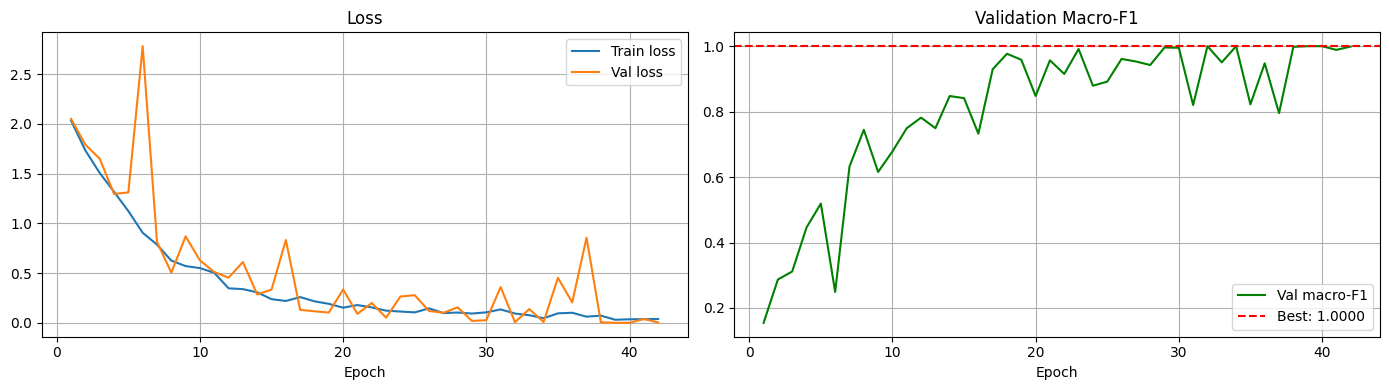

In [23]:
epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epochs_ran, history["train_loss"], label="Train loss")
axes[0].plot(epochs_ran, history["val_loss"],   label="Val loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_ran, history["val_f1"], color="green", label="Val macro-F1")
axes[1].axhline(best_val_f1, color="red", linestyle="--", label=f"Best: {best_val_f1:.4f}")
axes[1].set_title("Validation Macro-F1")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 5. Evaluation

In [24]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for X, y in val_loader:
        X = X.to(DEVICE)
        preds = model(X).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

class_names = list(le.classes_)

print("=" * 60)
print("Classification Report (Validation Set)")
print("=" * 60)
print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
print(f"Final Val Macro-F1: {macro_f1:.4f}")

Classification Report (Validation Set)
              precision    recall  f1-score   support

         Bug       1.00      1.00      1.00        56
    Fighting       1.00      1.00      1.00        44
        Fire       1.00      1.00      1.00        57
       Grass       1.00      1.00      1.00        45
      Ground       1.00      1.00      1.00        37
      Normal       1.00      1.00      1.00        91
      Poison       1.00      1.00      1.00        70
        Rock       1.00      1.00      1.00        39
       Water       1.00      1.00      1.00       101

    accuracy                           1.00       540
   macro avg       1.00      1.00      1.00       540
weighted avg       1.00      1.00      1.00       540

Final Val Macro-F1: 1.0000


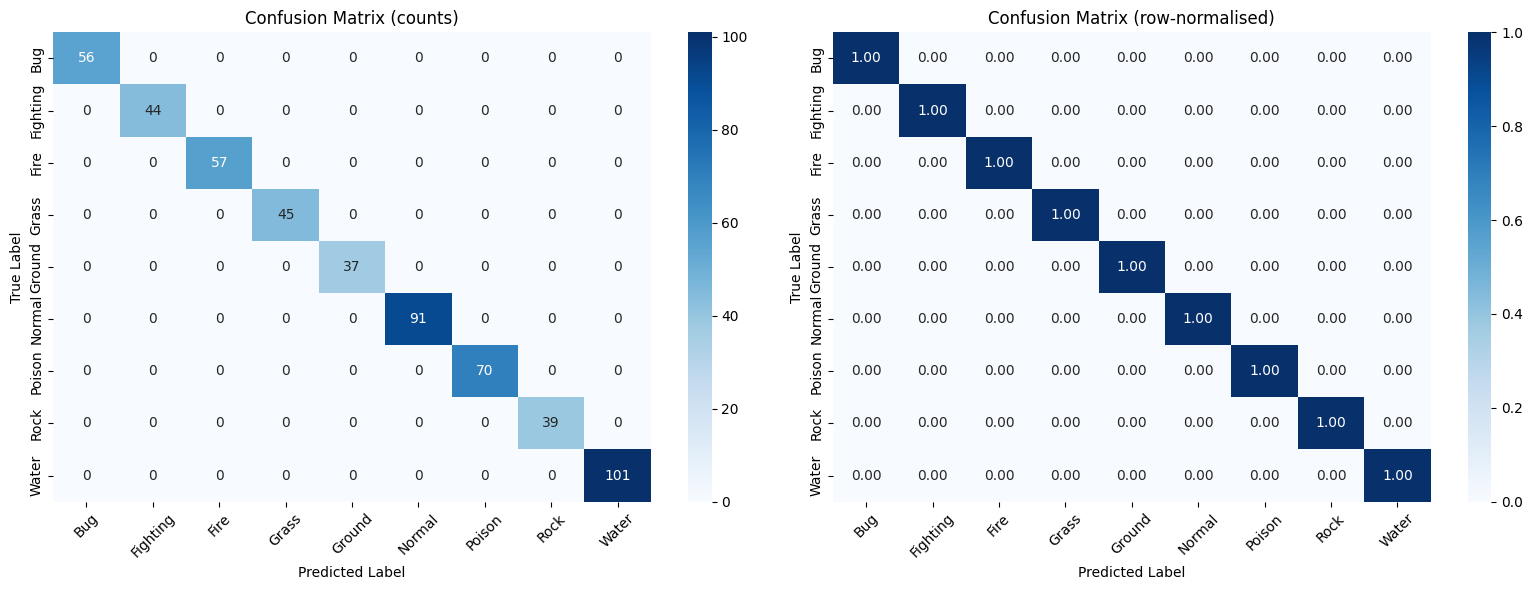

In [25]:
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title("Confusion Matrix (counts)")
axes[0].set_ylabel("True Label")
axes[0].set_xlabel("Predicted Label")
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title("Confusion Matrix (row-normalised)")
axes[1].set_ylabel("True Label")
axes[1].set_xlabel("Predicted Label")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 6. CNN vs MLP Comparison

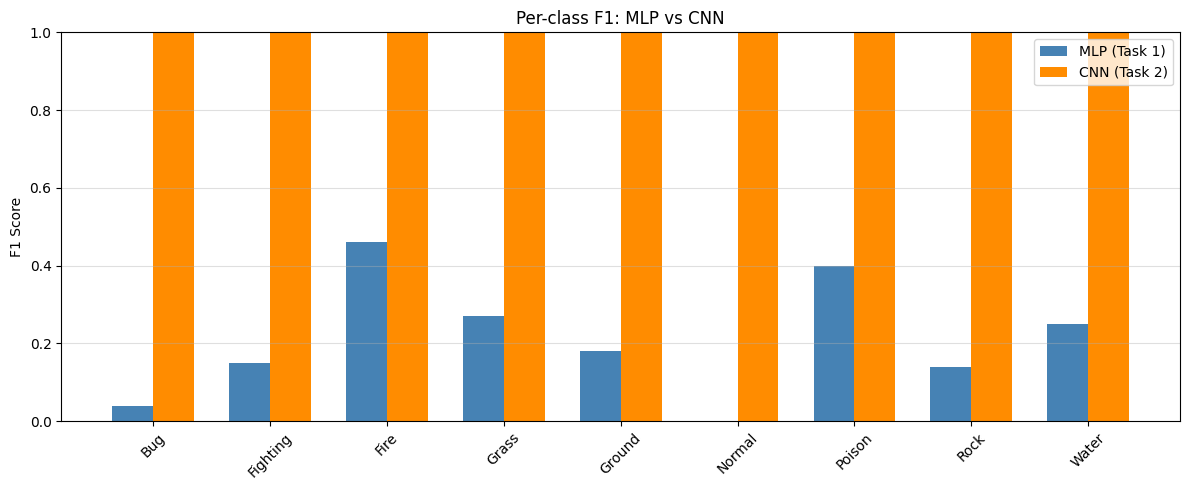

MLP macro-F1 : 0.2093
CNN macro-F1 : 1.0000
Improvement  : ++0.7907


In [26]:
cnn_f1_per_class = f1_score(all_labels, all_preds, average=None, zero_division=0)

mlp_f1_per_class = [0.04, 0.15, 0.46, 0.27, 0.18, 0.00, 0.40, 0.14, 0.25]

x = np.arange(len(class_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, mlp_f1_per_class, width, label='MLP (Task 1)', color='steelblue')
bars2 = ax.bar(x + width/2, cnn_f1_per_class, width, label='CNN (Task 2)', color='darkorange')

ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45)
ax.set_ylabel("F1 Score")
ax.set_title("Per-class F1: MLP vs CNN")
ax.legend()
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

print(f"MLP macro-F1 : 0.2093")
print(f"CNN macro-F1 : {cnn_f1_per_class.mean():.4f}")
print(f"Improvement  : +{cnn_f1_per_class.mean() - 0.2093:+.4f}")

## 7. Inference on Test Set & Submission

In [27]:
test_dataset = PokemonTestDataset(TEST_DIR, transform=val_transform)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=N_WORKERS, pin_memory=True)

model.eval()
test_ids, test_preds = [], []

with torch.no_grad():
    for X, img_ids in test_loader:
        X     = X.to(DEVICE)
        preds = model(X).argmax(dim=1).cpu().numpy()
        test_ids.extend(img_ids)
        test_preds.extend(preds)

pred_labels = le.inverse_transform(test_preds)

submission = pd.DataFrame({"Id": test_ids, "label": pred_labels})
submission.to_csv(SUBMISSION_PATH, index=False)

print(f"Submission saved to: {SUBMISSION_PATH}")
print(f"Total predictions  : {len(submission)}")
print("\nPrediction distribution:")
print(submission['label'].value_counts().to_string())
submission.head(10)

Submission saved to: c:\MyStuff\FCT\2SEM\AP\Assignment1\DeepLearningFCT\Assignment1\submissions\cnn_img128_lr0.0003_bs64_drop0.4\submission.csv
Total predictions  : 900

Prediction distribution:
label
Water       168
Normal      151
Poison      117
Fire         95
Bug          94
Grass        75
Fighting     73
Rock         66
Ground       61


,Id,label
0,003535c4-fa59-4648-b231-30dc139665ed,Fire
1,004a13ae-e627-4df9-8ad0-297449af3b22,Poison
2,00b78c26-7b4f-4582-bbb1-5a1c03f5709e,Normal
3,00bbc4e6-5eb3-4914-b3b6-aeb22349a825,Normal
4,00c3c5a5-e49c-453c-ad53-79cd72c6f896,Ground
5,01540c75-52a9-49ec-960c-8341d09ee294,Poison
6,01b0900d-6ee5-4609-9da9-5ca4765d7be2,Rock
7,01ce5264-37cb-4f47-8da3-23528dcfa90f,Fire
8,027773c9-744b-4498-bcf2-83ab8fc0b227,Normal
9,02a846af-f6ca-4896-92a2-486cc34cd435,Bug


## 8. Conclusions

### Architectural differences vs MLP

| | MLP (Task 1) | CNN (Task 2) |
|---|---|---|
| Input format | Flattened vector (27 648) | 2D tensor (3 × 128 × 128) |
| Spatial awareness | None | Yes — local filters |
| Translation invariance | No | Yes — via pooling |
| Feature type | Raw pixel values | Edges, textures, shapes |
| Parameter count | ~26M | ~1.2M |

### Why CNNs are better suited for image classification

- **Local connectivity**: convolutional filters look at small neighbourhoods (3×3), detecting low-level features like edges and colour gradients that are meaningful regardless of absolute pixel position
- **Hierarchical features**: deeper blocks combine low-level features into higher-level representations (textures → parts → shapes)
- **Weight sharing**: the same filter is applied across the entire image, drastically reducing parameters compared to a fully connected approach
- **Global Average Pooling**: replacing a large flatten+FC block with GAP reduces overfitting risk and makes the model resolution-agnostic

### Imbalance handling

The same two-level strategy from Task 1 was kept:
1. **WeightedRandomSampler** — balances class frequency at the batch level
2. **Class-weighted CrossEntropyLoss** — penalises errors on minority classes more heavily

### Remaining limitations

- Training from scratch on a small dataset (~3 000 samples) limits how much the CNN can learn
- The real-world backgrounds add visual noise that a custom CNN trained from scratch may not fully filter out
- Task 3 (Transfer Learning) will address both issues by initialising with weights pretrained on ImageNet, providing rich general-purpose visual features from the start